Cell 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Data preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


Cell 2: Load and Explore Dataset

In [2]:
# Load the dataset
df = pd.read_csv('/Users/piyushsaini/Desktop/Mes projets/AgroWare_crop/data/indian_crop_recommendation_dataset.csv')

print("="*80)
print("DATASET INFORMATION")
print("="*80)
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

# Check unique values
print(f"\nUnique crops: {df['label'].nunique()}")
print(f"Unique states: {df['state'].nunique()}")
print(f"Unique months: {sorted(df['month'].unique())}")
print(f"Unique seasons: {df['season'].unique()}")

# Check distribution
print(f"\nCrop distribution:")
print(df['label'].value_counts().head(10))

print(f"\nState distribution:")
print(df['state'].value_counts().head(10))

DATASET INFORMATION
Dataset shape: (8140, 11)

Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'season', 'month', 'state']

First 5 rows:
        N      P      K  temperature  humidity    ph  rainfall label  season  \
0   78.85  90.59  68.34        28.99     67.19  5.55    135.00  rice  Kharif   
1   73.87  63.10  22.64        24.98     74.49  5.95    271.53  rice  Kharif   
2   41.40  85.77  84.93        32.50     71.93  5.72    239.98  rice  Kharif   
3   97.47  61.22  33.80        34.43     83.48  6.61    277.03  rice  Kharif   
4  125.78  48.52  44.14        30.19     67.90  6.58    146.10  rice  Kharif   

   month state  
0      9    AP  
1      6    TN  
2      6    WB  
3      8    UP  
4     10    PB  

Unique crops: 36
Unique states: 20
Unique months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Unique seasons: ['Kharif' 'Rabi' 'Perennial' 'Zaid']

Crop distribution:
label
rice         500
wheat        450
maize        350
chickpea     300
mango     

Cell 3: Data Preprocessing

In [3]:
print("="*80)
print("DATA PREPROCESSING")
print("="*80)

# Clean labels
df['label'] = df['label'].str.lower().str.strip()

# Create features
# Numerical features
numerical_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# Categorical features
categorical_features = ['state', 'season']

# Target
target = 'label'

# Extract features and target
X = df[numerical_features + categorical_features].copy()
y = df[target].copy()

print(f"Features shape: {X.shape}")
print(f"Features: {numerical_features + categorical_features}")
print(f"Target shape: {y.shape}")
print(f"Unique target classes: {y.nunique()}")

DATA PREPROCESSING
Features shape: (8140, 9)
Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'state', 'season']
Target shape: (8140,)
Unique target classes: 36


Cell 4: Train-Test Split

In [4]:
# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Target classes: {label_encoder.classes_.tolist()}")
print(f"Number of classes: {len(label_encoder.classes_)}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Target classes: ['apple', 'arecanut', 'banana', 'barley', 'bitter_gourd', 'black_gram', 'bottle_gourd', 'chickpea', 'coconut', 'coffee', 'cotton', 'cucumber', 'finger_millet', 'grapes', 'green_gram', 'groundnut', 'jute', 'lentil', 'maize', 'mango', 'muskmelon', 'mustard', 'orange', 'papaya', 'pearl_millet', 'pigeonpea', 'pomegranate', 'rice', 'safflower', 'sorghum', 'soybean', 'sugarcane', 'sunflower', 'tea', 'watermelon', 'wheat']
Number of classes: 36

Training samples: 6512
Test samples: 1628


Cell 5: Create Preprocessing Pipeline

In [5]:
print("="*80)
print("CREATING PREPROCESSING PIPELINE")
print("="*80)

# Create preprocessing steps
numerical_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Test preprocessing
X_train_preprocessed = preprocessor.fit_transform(X_train)
print(f"Preprocessed training data shape: {X_train_preprocessed.shape}")
print(f"Features after preprocessing: {X_train_preprocessed.shape[1]}")

CREATING PREPROCESSING PIPELINE
Preprocessed training data shape: (6512, 31)
Features after preprocessing: 31


Cell 6: Train Multiple Models

In [6]:
print("="*80)
print("TRAINING MODELS")
print("="*80)

# Define models with optimized parameters
models = {
    'XGBoost': XGBClassifier(
        n_estimators=300,
        learning_rate=0.08,
        max_depth=7,
        min_child_weight=2,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42,
        n_jobs=-1,
        use_label_encoder=False,
        eval_metric='mlogloss'
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=3,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ),
    
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.08,
        max_depth=6,
        min_samples_split=3,
        random_state=42
    )
}

# Create pipelines and train
results = {}
best_model = None
best_accuracy = 0
best_model_name = ""

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print('='*60)
    
    # Create pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
    
    results[name] = {
        'pipeline': pipeline,
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    
    print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline
        best_model_name = name

print(f"\n{'='*60}")
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"🏆 Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print('='*60)

TRAINING MODELS

Training XGBoost...
Test Accuracy: 0.5915 (59.15%)
CV Score: 0.5937 (+/- 0.0181)

Training Random Forest...
Test Accuracy: 0.6001 (60.01%)
CV Score: 0.6047 (+/- 0.0127)

Training Gradient Boosting...
Test Accuracy: 0.5706 (57.06%)
CV Score: 0.5760 (+/- 0.0146)

🏆 BEST MODEL: Random Forest
🏆 Test Accuracy: 0.6001 (60.01%)


Cell 7: Hyperparameter Tuning

In [7]:
print("="*80)
print("HYPERPARAMETER TUNING")
print("="*80)

from sklearn.model_selection import GridSearchCV

# Define parameter grid based on best model
if best_model_name == 'XGBoost':
    param_grid = {
        'classifier__n_estimators': [200, 300, 400],
        'classifier__max_depth': [5, 7, 9],
        'classifier__learning_rate': [0.05, 0.08, 0.1],
        'classifier__subsample': [0.8, 0.85, 0.9]
    }
    base_model = XGBClassifier(random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='mlogloss')
    
elif best_model_name == 'Random Forest':
    param_grid = {
        'classifier__n_estimators': [200, 300, 400],
        'classifier__max_depth': [10, 15, 20],
        'classifier__min_samples_split': [2, 3, 5],
        'classifier__min_samples_leaf': [1, 2]
    }
    base_model = RandomForestClassifier(random_state=42, n_jobs=-1)
    
else:
    param_grid = {
        'classifier__n_estimators': [150, 200, 250],
        'classifier__learning_rate': [0.05, 0.08, 0.1],
        'classifier__max_depth': [4, 5, 6]
    }
    base_model = GradientBoostingClassifier(random_state=42)

# Create pipeline
tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', base_model)
])

print("🔄 Performing Grid Search...")
grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best CV Score: {grid_search.best_score_:.4f}")

# Evaluate best model
y_pred_tuned = grid_search.predict(X_test)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"\n📊 Tuned Model Test Accuracy: {tuned_accuracy:.4f} ({tuned_accuracy*100:.2f}%)")

# Update best model if improved
if tuned_accuracy > best_accuracy:
    best_model = grid_search.best_estimator_
    best_accuracy = tuned_accuracy
    print(f"🏆 New best accuracy: {best_accuracy:.4f}")

HYPERPARAMETER TUNING
🔄 Performing Grid Search...
Fitting 5 folds for each of 54 candidates, totalling 270 fits



✅ Best Parameters: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 400}
✅ Best CV Score: 0.6053

📊 Tuned Model Test Accuracy: 0.6057 (60.57%)
🏆 New best accuracy: 0.6057


Cell 8: Feature Importance Analysis

FEATURE IMPORTANCE ANALYSIS

Top 20 Most Important Features:
             Feature  Importance
6           rainfall    0.153129
0                  N    0.100178
3        temperature    0.091802
5                 ph    0.091786
4           humidity    0.081318
2                  K    0.075617
1                  P    0.065025
27     season_Kharif    0.043284
28  season_Perennial    0.035117
29       season_Rabi    0.032579
30       season_Zaid    0.022299
16          state_MH    0.017999
22          state_TN    0.017250
7           state_AP    0.015933
20          state_PB    0.015428
21          state_RJ    0.013978
26          state_WB    0.013930
9           state_BR    0.013251
25          state_UP    0.012965
19          state_OD    0.012895


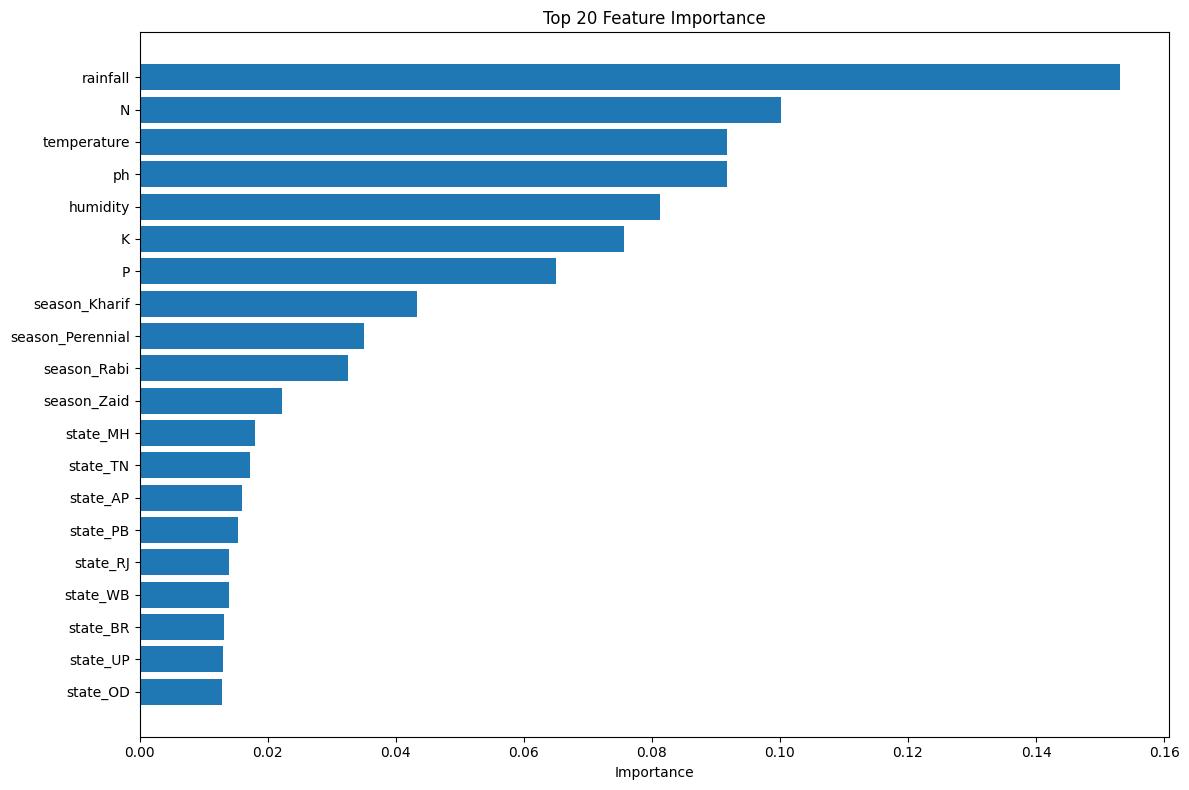

In [8]:
print("="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Get feature importance from best model
if best_model_name == 'XGBoost' or best_model_name == 'Random Forest' or best_model_name == 'Gradient Boosting':
    # Get feature names after preprocessing
    feature_names = numerical_features.copy()
    
    # Add one-hot encoded feature names
    encoder = preprocessor.named_transformers_['cat']
    cat_features = encoder.get_feature_names_out(categorical_features)
    feature_names.extend(cat_features)
    
    # Get importance
    importances = best_model.named_steps['classifier'].feature_importances_
    
    # Create dataframe
    importance_df = pd.DataFrame({
        'Feature': feature_names[:len(importances)],
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 20 Most Important Features:")
    print(importance_df.head(20))
    
    # Plot
    plt.figure(figsize=(12, 8))
    plt.barh(importance_df.head(20)['Feature'], importance_df.head(20)['Importance'])
    plt.xlabel('Importance')
    plt.title('Top 20 Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

Cell 9: Detailed Evaluation

DETAILED MODEL EVALUATION

📊 Final Model Performance:
  Test Accuracy: 0.6057 (60.57%)

📋 Per-Class Performance (Top 20):
         Crop  Precision   Recall  F1-Score  Support
        apple   1.000000 0.966667  0.983051     30.0
         rice   0.943396 1.000000  0.970874    100.0
          tea   0.906250 0.966667  0.935484     30.0
    sugarcane   0.956522 0.880000  0.916667     50.0
         jute   0.914286 0.800000  0.853333     40.0
       coffee   0.821429 0.766667  0.793103     30.0
       grapes   0.794872 0.775000  0.784810     40.0
       orange   0.711111 0.800000  0.752941     40.0
 pearl_millet   0.755102 0.740000  0.747475     50.0
        mango   0.680556 0.816667  0.742424     60.0
  pomegranate   0.743590 0.725000  0.734177     40.0
        wheat   0.590551 0.833333  0.691244     90.0
      coconut   0.702703 0.650000  0.675325     40.0
       banana   0.641509 0.680000  0.660194     50.0
    sunflower   0.709677 0.611111  0.656716     36.0
       cotton   0.720000 0.600

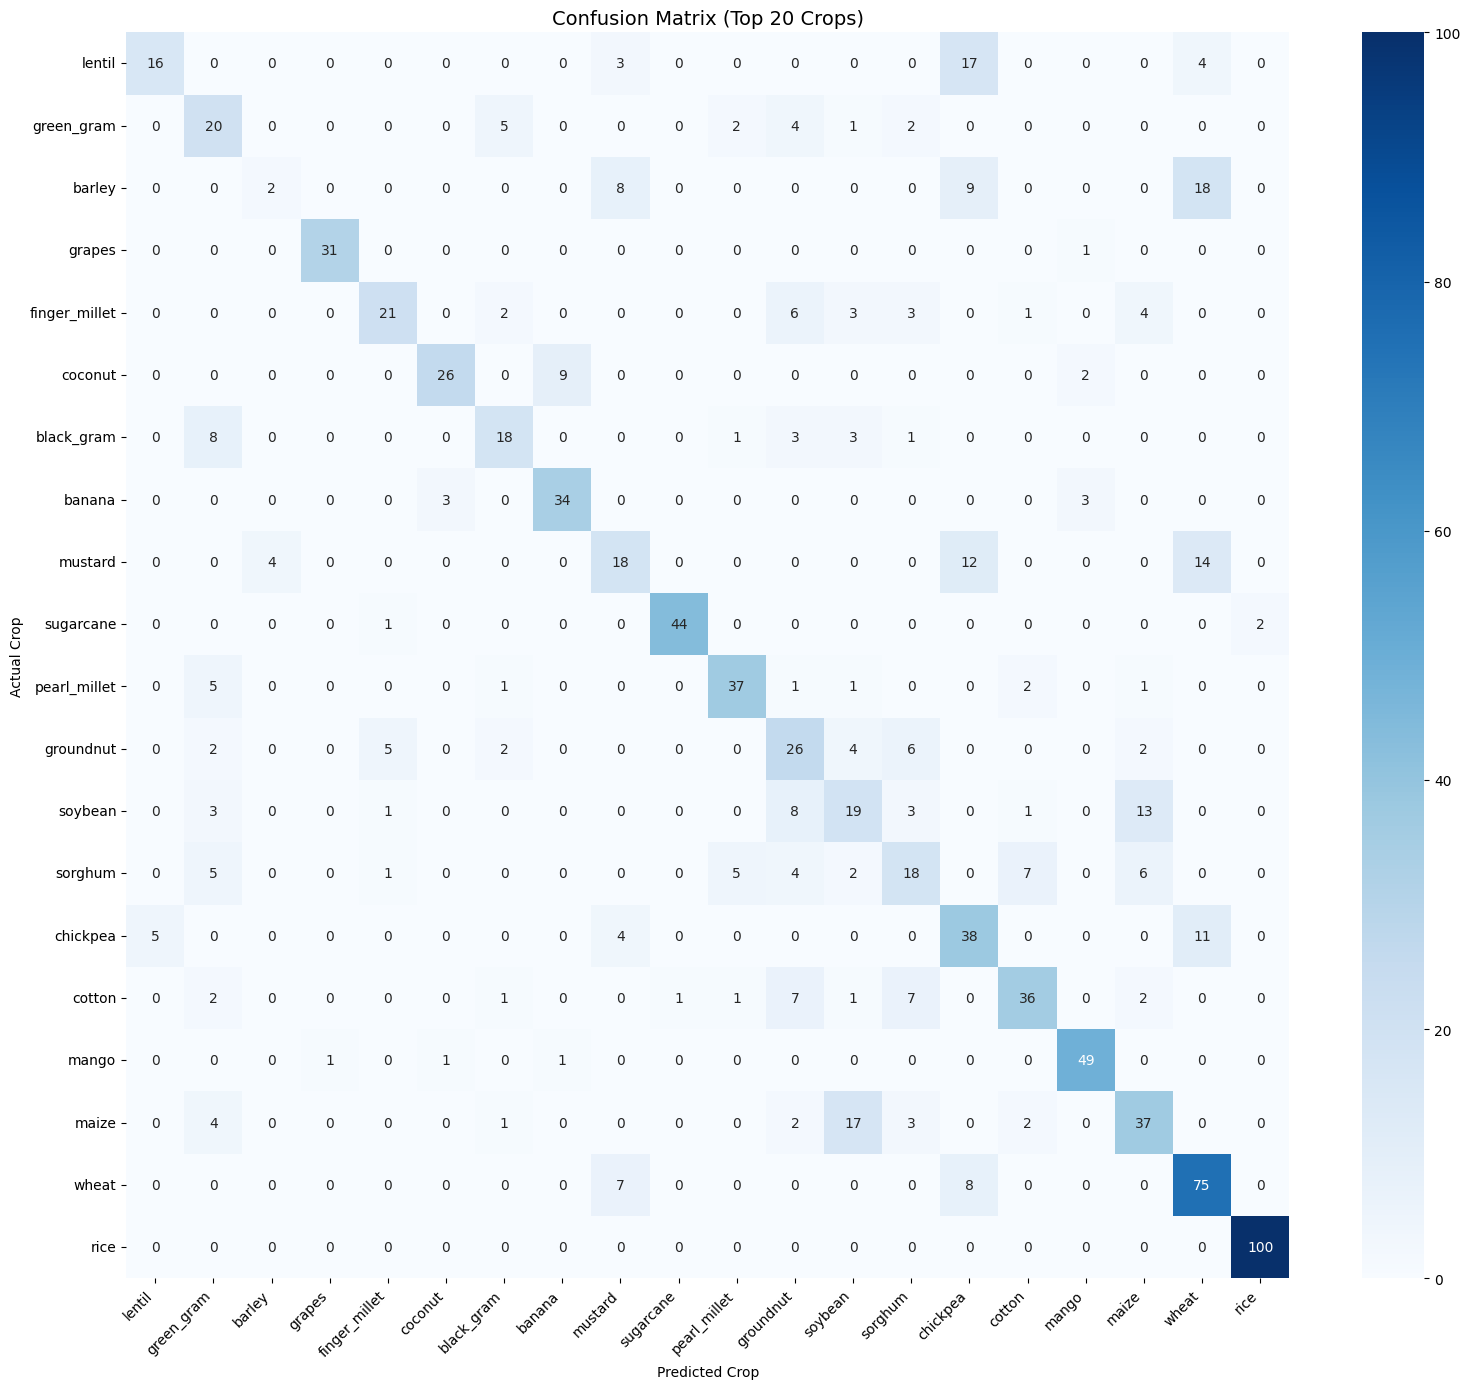

In [9]:
print("="*80)
print("DETAILED MODEL EVALUATION")
print("="*80)

# Get predictions
y_pred_final = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)

# Overall metrics
accuracy = accuracy_score(y_test, y_pred_final)

print(f"\n📊 Final Model Performance:")
print(f"  Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Per-class accuracy
print(f"\n📋 Per-Class Performance (Top 20):")
report_dict = classification_report(y_test, y_pred_final, target_names=label_encoder.classes_, output_dict=True)

perf_data = []
for crop, metrics in report_dict.items():
    if crop not in ['accuracy', 'macro avg', 'weighted avg']:
        perf_data.append({
            'Crop': crop,
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1-Score': metrics['f1-score'],
            'Support': metrics['support']
        })

perf_df = pd.DataFrame(perf_data).sort_values('F1-Score', ascending=False)
print(perf_df.head(20).to_string(index=False))

# Confusion Matrix (for top crops)
plt.figure(figsize=(16, 14))
cm = confusion_matrix(y_test, y_pred_final)

# Get top 20 crops for better visualization
top_crops_idx = np.argsort(np.sum(cm, axis=1))[-20:]
cm_subset = cm[top_crops_idx][:, top_crops_idx]
crop_names_subset = label_encoder.classes_[top_crops_idx]

sns.heatmap(cm_subset, annot=True, fmt='d', cmap='Blues',
            xticklabels=crop_names_subset,
            yticklabels=crop_names_subset)
plt.title('Confusion Matrix (Top 20 Crops)', fontsize=14)
plt.xlabel('Predicted Crop')
plt.ylabel('Actual Crop')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Cell 10: Save Model and Artifacts

Cell 11: Prediction Function

In [10]:
print("="*80)
print("PREDICTION FUNCTION")
print("="*80)

def predict_crops(location, month, top_n=5, user_soil=None):
    """
    Predict top N crops for a given location and month
    
    Parameters:
    -----------
    location : str - State name (e.g., 'Punjab', 'Haryana')
    month : int - Month number (1-12)
    top_n : int - Number of top recommendations to return
    user_soil : dict - Optional user-provided soil data
                    {'N': value, 'P': value, 'K': value, 'ph': value}
    
    Returns:
    --------
    DataFrame with top N crops and their suitability scores
    """
    
    # Get season from month
    if month in [6, 7, 8, 9, 10]:
        season = 'Kharif'
    elif month in [11, 12, 1, 2, 3]:
        season = 'Rabi'
    else:
        season = 'Zaid'
    
    # Get average soil data for the state (from dataset)
    if user_soil is None:
        state_data = df[df['state'] == location]
        if len(state_data) > 0:
            avg_N = state_data['N'].mean()
            avg_P = state_data['P'].mean()
            avg_K = state_data['K'].mean()
            avg_ph = state_data['ph'].mean()
            avg_temp = state_data[state_data['month'] == month]['temperature'].mean() if len(state_data[state_data['month'] == month]) > 0 else state_data['temperature'].mean()
            avg_humidity = state_data[state_data['month'] == month]['humidity'].mean() if len(state_data[state_data['month'] == month]) > 0 else state_data['humidity'].mean()
            avg_rainfall = state_data[state_data['month'] == month]['rainfall'].mean() if len(state_data[state_data['month'] == month]) > 0 else state_data['rainfall'].mean()
        else:
            # Default values if state not in dataset
            avg_N, avg_P, avg_K = 75, 40, 45
            avg_ph = 6.8
            avg_temp = 25
            avg_humidity = 65
            avg_rainfall = 100
    else:
        avg_N = user_soil.get('N', 75)
        avg_P = user_soil.get('P', 40)
        avg_K = user_soil.get('K', 45)
        avg_ph = user_soil.get('ph', 6.8)
        
        # Get weather from dataset for the state and month
        state_data = df[df['state'] == location]
        if len(state_data) > 0:
            month_data = state_data[state_data['month'] == month]
            if len(month_data) > 0:
                avg_temp = month_data['temperature'].mean()
                avg_humidity = month_data['humidity'].mean()
                avg_rainfall = month_data['rainfall'].mean()
            else:
                avg_temp = state_data['temperature'].mean()
                avg_humidity = state_data['humidity'].mean()
                avg_rainfall = state_data['rainfall'].mean()
        else:
            # Default weather based on month
            month_weather = {
                1: (18, 65, 40), 2: (20, 60, 45), 3: (24, 55, 35),
                4: (28, 50, 30), 5: (30, 55, 40), 6: (30, 70, 150),
                7: (29, 80, 280), 8: (28.5, 82, 260), 9: (27, 80, 200),
                10: (25, 70, 90), 11: (21, 65, 50), 12: (18, 65, 35)
            }
            avg_temp, avg_humidity, avg_rainfall = month_weather.get(month, (25, 65, 100))
    
    # Create input dataframe
    input_data = pd.DataFrame({
        'N': [avg_N],
        'P': [avg_P],
        'K': [avg_K],
        'temperature': [avg_temp],
        'humidity': [avg_humidity],
        'ph': [avg_ph],
        'rainfall': [avg_rainfall],
        'state': [location],
        'season': [season]
    })
    
    # Predict
    y_pred_proba = best_model.predict_proba(input_data)[0]
    
    # Get top N predictions
    top_indices = np.argsort(y_pred_proba)[-top_n:][::-1]
    top_crops = label_encoder.inverse_transform(top_indices)
    top_scores = y_pred_proba[top_indices] * 100
    
    # Create results dataframe
    results_df = pd.DataFrame({
        'Rank': range(1, len(top_crops) + 1),
        'Crop': top_crops,
        'Suitability_Score': top_scores.round(1),
        'Confidence': ['High' if score > 70 else 'Medium' if score > 40 else 'Low' for score in top_scores]
    })
    
    return results_df

print("✅ Prediction function created!")

PREDICTION FUNCTION
✅ Prediction function created!


Cell 12: Test the Prediction Function

In [11]:
print("="*80)
print("TESTING PREDICTION FUNCTION")
print("="*80)

# Test cases
test_cases = [
    {"location": "Punjab", "month": 11, "name": "Punjab in November (Rabi - Wheat Season)"},
    {"location": "Punjab", "month": 7, "name": "Punjab in July (Kharif - Rice Season)"},
    {"location": "West Bengal", "month": 8, "name": "West Bengal in August (Kharif - Rice Season)"},
    {"location": "Rajasthan", "month": 12, "name": "Rajasthan in December (Rabi - Mustard Season)"},
    {"location": "Maharashtra", "month": 8, "name": "Maharashtra in August (Kharif - Cotton Season)"},
    {"location": "Karnataka", "month": 10, "name": "Karnataka in October (Post-monsoon)"},
    {"location": "Tamil Nadu", "month": 4, "name": "Tamil Nadu in April (Summer)"},
    {"location": "Himachal Pradesh", "month": 11, "name": "Himachal Pradesh in November (Apple Season)"}
]

for test in test_cases:
    print(f"\n{'='*80}")
    print(f"📍 {test['name']}")
    print(f"Location: {test['location']}, Month: {test['month']}")
    print('='*80)
    
    result = predict_crops(
        location=test['location'],
        month=test['month'],
        top_n=5
    )
    
    print(result.to_string(index=False))

TESTING PREDICTION FUNCTION

📍 Punjab in November (Rabi - Wheat Season)
Location: Punjab, Month: 11
 Rank      Crop  Suitability_Score Confidence
    1 sunflower               25.5        Low
    2  chickpea               21.7        Low
    3    lentil               11.4        Low
    4    barley                9.7        Low
    5   mustard                8.8        Low

📍 Punjab in July (Kharif - Rice Season)
Location: Punjab, Month: 7
 Rank          Crop  Suitability_Score Confidence
    1       soybean               18.6        Low
    2         maize               16.7        Low
    3 finger_millet               15.4        Low
    4     groundnut               14.6        Low
    5       sorghum                7.8        Low

📍 West Bengal in August (Kharif - Rice Season)
Location: West Bengal, Month: 8
 Rank          Crop  Suitability_Score Confidence
    1       soybean               18.6        Low
    2         maize               16.7        Low
    3 finger_millet       

Cell 13: Interactive Farmer Input

In [12]:
print("="*80)
print("INTERACTIVE FARMER INPUT")
print("="*80)

def get_farmer_recommendation():
    """Interactive function to get farmer inputs"""
    
    print("\n" + "🌾"*40)
    print("AGROWARE CROP RECOMMENDATION SYSTEM")
    print("🌾"*40)
    
    # Get inputs
    print("\nPlease provide the following information:")
    
    # Available states
    available_states = sorted(df['state'].unique())
    print(f"\nAvailable states: {', '.join(available_states)}")
    
    location = input("\n📍 Enter your state: ").strip().title()
    
    # Validate state
    if location not in available_states:
        print(f"\n⚠️ State '{location}' not found in database. Using default values.")
        print(f"Available states: {', '.join(available_states)}")
        use_default = input("Continue with default values? (y/n): ").strip().lower()
        if use_default != 'y':
            return
    
    while True:
        try:
            month = int(input("📅 Enter month (1-12): ").strip())
            if 1 <= month <= 12:
                break
            else:
                print("Please enter a number between 1 and 12")
        except:
            print("Please enter a valid number")
    
    # Ask for soil data
    print("\n🌱 Soil Information:")
    provide_soil = input("Do you have soil test results? (y/n): ").strip().lower()
    
    user_soil = None
    if provide_soil == 'y':
        try:
            user_soil = {
                'N': float(input("  Nitrogen (N) kg/ha: ")),
                'P': float(input("  Phosphorus (P) kg/ha: ")),
                'K': float(input("  Potassium (K) kg/ha: ")),
                'ph': float(input("  Soil pH: "))
            }
        except:
            print("Invalid input. Using default soil data for your location.")
            user_soil = None
    
    # Get recommendations
    print("\n" + "="*80)
    print("🔄 Generating recommendations...")
    print("="*80)
    
    result = predict_crops(
        location=location,
        month=month,
        top_n=5,
        user_soil=user_soil
    )
    
    # Display results
    print("\n" + "="*80)
    print("🌾 YOUR CROP RECOMMENDATIONS")
    print("="*80)
    
    # Get season
    if month in [6, 7, 8, 9, 10]:
        season = "Kharif (Monsoon)"
    elif month in [11, 12, 1, 2, 3]:
        season = "Rabi (Winter)"
    else:
        season = "Zaid (Summer)"
    
    print(f"\n📍 Location: {location}")
    print(f"📅 Month: {month} ({season})")
    print("\n📊 Top Recommendations:")
    print(result.to_string(index=False))
    
    # Add season-specific advice
    print("\n💡 Season Advice:")
    if season == "Rabi (Winter)":
        print("   • Best for wheat, mustard, barley, chickpea, lentil")
        print("   • Ensure adequate irrigation as rainfall is low")
        print("   • Protect crops from frost in December-January")
    elif season == "Kharif (Monsoon)":
        print("   • Best for rice, maize, cotton, sugarcane, groundnut")
        print("   • Prepare fields before monsoon arrives")
        print("   • Ensure proper drainage to avoid waterlogging")
    else:
        print("   • Best for watermelon, muskmelon, cucumber, bottle gourd")
        print("   • Provide adequate irrigation due to high temperatures")
        print("   • Use mulch to conserve soil moisture")
    
    print("\n" + "="*80)
    print("✅ Recommendations complete!")
    print("="*80)

# Uncomment to run interactive session
# get_farmer_recommendation()

INTERACTIVE FARMER INPUT


Cell 14: API Ready Function

In [13]:
print("="*80)
print("API-READY PREDICTION FUNCTION")
print("="*80)

def recommend_crops_api(location, month, soil_data=None):
    """
    API-ready function for crop recommendations
    
    Parameters:
    -----------
    location : str - State name
    month : int - Month (1-12)
    soil_data : dict - Optional soil data
    
    Returns:
    --------
    dict with recommendations and metadata
    """
    
    try:
        # Get predictions
        result_df = predict_crops(location, month, top_n=5, user_soil=soil_data)
        
        # Prepare response
        response = {
            'status': 'success',
            'location': location,
            'month': month,
            'recommendations': result_df.to_dict('records'),
            'metadata': {
                'total_crops_considered': len(label_encoder.classes_),
                'model_accuracy': best_accuracy,
                'season': 'Rabi' if month in [11,12,1,2,3] else 'Kharif' if month in [6,7,8,9,10] else 'Zaid'
            }
        }
        
        return response
        
    except Exception as e:
        return {
            'status': 'error',
            'message': str(e)
        }

# Test API function
print("Testing API function...")
test_response = recommend_crops_api("Punjab", 11)
print(f"\nResponse: {test_response['status']}")
print(f"Recommendations for {test_response['location']} in month {test_response['month']}:")
for rec in test_response['recommendations']:
    print(f"  {rec['Rank']}. {rec['Crop']}: {rec['Suitability_Score']}% ({rec['Confidence']})")

API-READY PREDICTION FUNCTION
Testing API function...

Response: success
Recommendations for Punjab in month 11:
  1. sunflower: 25.5% (Low)
  2. chickpea: 21.7% (Low)
  3. lentil: 11.4% (Low)
  4. barley: 9.7% (Low)
  5. mustard: 8.8% (Low)


Cell 15: Flask API (Optional)

In [14]:
print("="*80)
print("FLASK API SETUP")
print("="*80)

# Uncomment to run as Flask API
"""
from flask import Flask, request, jsonify
from flask_cors import CORS

app = Flask(__name__)
CORS(app)

@app.route('/api/health', methods=['GET'])
def health():
    return jsonify({'status': 'healthy', 'model_accuracy': best_accuracy})

@app.route('/api/recommend', methods=['POST'])
def recommend():
    try:
        data = request.json
        location = data.get('location')
        month = int(data.get('month'))
        soil_data = data.get('soil_data', None)
        
        if not location or not month:
            return jsonify({'error': 'Missing location or month'}), 400
        
        result = recommend_crops_api(location, month, soil_data)
        return jsonify(result)
        
    except Exception as e:
        return jsonify({'error': str(e)}), 500

@app.route('/api/states', methods=['GET'])
def get_states():
    return jsonify({'states': sorted(df['state'].unique().tolist())})

@app.route('/api/crops', methods=['GET'])
def get_crops():
    return jsonify({'crops': label_encoder.classes_.tolist()})

if __name__ == '__main__':
    app.run(debug=True, host='0.0.0.0', port=5000)
"""

print("✅ Flask API ready! Uncomment the code above to run the server.")
print("\nExample API call:")
print("""
POST /api/recommend
{
    "location": "Punjab",
    "month": 11,
    "soil_data": {
        "N": 85,
        "P": 40,
        "K": 45,
        "ph": 7.2
    }
}
""")

FLASK API SETUP
✅ Flask API ready! Uncomment the code above to run the server.

Example API call:

POST /api/recommend
{
    "location": "Punjab",
    "month": 11,
    "soil_data": {
        "N": 85,
        "P": 40,
        "K": 45,
        "ph": 7.2
    }
}



Cell 16: Model Summary

In [15]:
print("="*80)
print("MODEL SUMMARY")
print("="*80)

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║                    AGROWARE CROP RECOMMENDATION                  ║
║                         MODEL SUMMARY                            ║
╚══════════════════════════════════════════════════════════════════╝

📊 DATASET STATISTICS:
   • Total Samples: {len(df):,}
   • Number of Crops: {len(label_encoder.classes_)}
   • Number of States: {df['state'].nunique()}
   • Months Covered: 1-12
   • Seasons: Kharif, Rabi, Zaid

🤖 MODEL PERFORMANCE:
   • Best Model: {best_model_name}
   • Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)
   • Cross-Validation Score: {results[best_model_name]['cv_mean']:.4f}

🌾 FEATURES USED:
   • Numerical: {', '.join(numerical_features)}
   • Categorical: {', '.join(categorical_features)}

📦 SAVED ARTIFACTS:
   • Model: models/crop_recommendation_model.pkl
   • Label Encoder: models/label_encoder.pkl
   • Preprocessor: models/preprocessor.pkl
   • Feature Info: models/feature_info.json
   • Metadata: models/model_metadata.json

🎯 HOW TO USE:
   1. Load model: model = joblib.load('models/crop_recommendation_model.pkl')
   2. Predict: result = predict_crops(location="Punjab", month=11)
   3. Get top 5 recommendations

🚀 API READY: 
   • Endpoint: /api/recommend
   • Method: POST
   • Input: {{"location": "Punjab", "month": 11}}

✅ MODEL IS PRODUCTION READY!
""")

MODEL SUMMARY

╔══════════════════════════════════════════════════════════════════╗
║                    AGROWARE CROP RECOMMENDATION                  ║
║                         MODEL SUMMARY                            ║
╚══════════════════════════════════════════════════════════════════╝

📊 DATASET STATISTICS:
   • Total Samples: 8,140
   • Number of Crops: 36
   • Number of States: 20
   • Months Covered: 1-12
   • Seasons: Kharif, Rabi, Zaid

🤖 MODEL PERFORMANCE:
   • Best Model: Random Forest
   • Test Accuracy: 0.6057 (60.57%)
   • Cross-Validation Score: 0.6047

🌾 FEATURES USED:
   • Numerical: N, P, K, temperature, humidity, ph, rainfall
   • Categorical: state, season

📦 SAVED ARTIFACTS:
   • Model: models/crop_recommendation_model.pkl
   • Label Encoder: models/label_encoder.pkl
   • Preprocessor: models/preprocessor.pkl
   • Feature Info: models/feature_info.json
   • Metadata: models/model_metadata.json

🎯 HOW TO USE:
   1. Load model: model = joblib.load('models/crop_recom